In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ppb00x/eeg-neuroheadset/eeg-headset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ppb00x/eeg-neuroheadset/eeg-headset.csv')


Data exploration

In [4]:
df

,AF3,F7,F3,FC5,T7,P,O1,O2,P8,T8,FC6,F4,F8,AF4,eye_state
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,1
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,1
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,1
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,1
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14975,4281.03,3990.26,4245.64,4116.92,4333.85,4614.36,4074.87,4625.64,4203.08,4221.54,4171.28,4269.23,4593.33,4340.51,2
14976,4276.92,3991.79,4245.13,4110.77,4332.82,4615.38,4073.33,4621.54,4194.36,4217.44,4162.56,4259.49,4590.26,4333.33,2
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49,2
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77,2


In [5]:
for col_name, col_data in df.items():
    print(f"Column: {col_name} Min value: {col_data.min()} Max value: {col_data.max()}")
    print("-" * 20)

Column: AF3 Min value: 1030.77 Max value: 309231.0
--------------------
Column: F7 Min value: 2830.77 Max value: 7804.62
--------------------
Column: F3 Min value: 1040.0 Max value: 6880.51
--------------------
Column: FC5 Min value: 2453.33 Max value: 642564.0
--------------------
Column: T7 Min value: 2089.74 Max value: 6474.36
--------------------
Column: P Min value: 2768.21 Max value: 362564.0
--------------------
Column: O1 Min value: 2086.15 Max value: 567179.0
--------------------
Column: O2 Min value: 4567.18 Max value: 7264.1
--------------------
Column: P8 Min value: 1357.95 Max value: 265641.0
--------------------
Column: T8 Min value: 1816.41 Max value: 6674.36
--------------------
Column: FC6 Min value: 3273.33 Max value: 6823.08
--------------------
Column: F4 Min value: 2257.95 Max value: 7002.56
--------------------
Column: F8 Min value: 86.6667 Max value: 152308.0
--------------------
Column: AF4 Min value: 1366.15 Max value: 715897.0
--------------------
Column: eye_

In [6]:
def plot_eeg_signals(df, n_rows=10):

    # Requested number of rows
    df_subset = df.head(n_rows)
    
    # All columns except 'eye_state'
    value_cols = [col for col in df_subset.columns if col != 'eye_state']
    num_plots = len(value_cols)
    
    # Color list based on 'eye_state'
    colors = []
    for state in df_subset['eye_state']:
        if state == 1:
            colors.append('green')
        elif state == 2:
            colors.append('blue')
        else:
            colors.append('red')
            
    # Dynamically change marker size and line width based on row count
    if n_rows <= 15:
        marker_size = 70
        line_width = 1.5
    elif n_rows <= 100:
        marker_size = 20
        line_width = 1.0
    else:
        marker_size = 8  
        line_width = 0.6
    
    # Vertically stacked subplots
    fig, axs = plt.subplots(nrows=num_plots, ncols=1, figsize=(12, num_plots * 1.5), sharex=True)
    
    if num_plots == 1:
        axs = [axs]
        
    fig.subplots_adjust(hspace=0.2)
    
    # Plot each column
    for i, col in enumerate(value_cols):
        ax = axs[i]
        
        # The connecting line
        ax.plot(df_subset.index, df_subset[col], color='darkgray', linestyle='-', linewidth=line_width, zorder=1)
        
        # The colored dots 
        ax.scatter(df_subset.index, df_subset[col], c=colors, s=marker_size, zorder=2)
        
        # Layout and styling
        ax.set_ylabel(col, rotation=0, loc='center', labelpad=45, fontsize=10, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Remove side borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if i < num_plots - 1:
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(bottom=False)

    axs[-1].set_xlabel("Row Index", fontsize=12, fontweight='bold')
    
    plt.show()

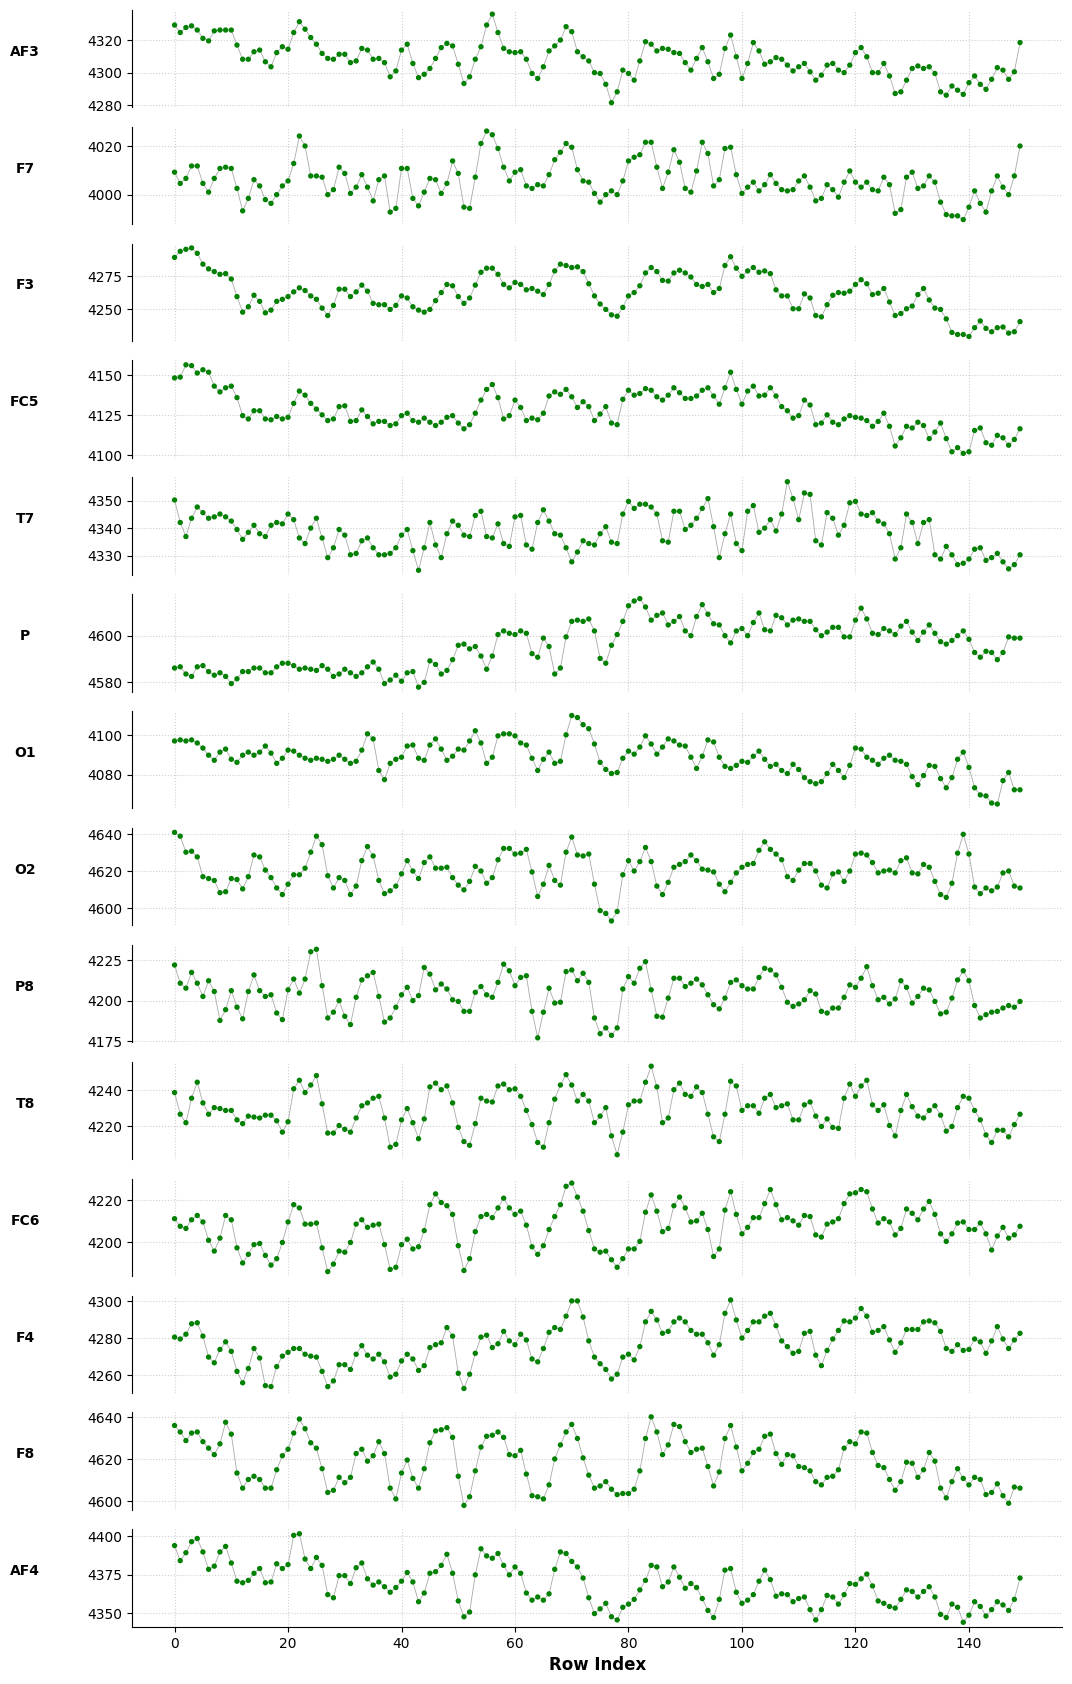

In [7]:
plot_eeg_signals(df, n_rows=150)